# Nepali News Classification
## Exploratory Data Analysis (EDA)

This notebook explores the merged Nepali news dataset collected from:

- News24
- Ratopati
- Setopati

The goal is to understand the dataset before training machine learning models.

In [2]:
import sys

print(sys.executable)

/Users/orishashakya/Desktop/Nepali-News-Classification/venv/bin/python


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [4]:
%pip install wordcloud seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_csv("../data/processed/news_dataset_processed.csv")

print(df.shape)

df.head()

(1929, 7)


,website,website_category,label,title,content,url,text
0,Ratopati,स्वास्थ्य,Health,किन आन्दोलित छन् भक्तपुर क्यान्सर अस्पतालका कर...,काठमाडौँ । भक्तपुर क्यान्सर अस्पतालमा कार्यरत ...,https://www.ratopati.com/story/579305/why-are-...,किन आन्दोलित छन् भक्तपुर क्यान्सर अस्पतालका कर...
1,Setopati,ग्लोबल,International,"घरको ग्यारेजबाट थालेको व्यवसाय, अहिले वर्षमा १...","आठ वर्षभन्दा बढी भयो, भक्तपुरका दिपेन्द्र खड्क...",https://www.setopati.com/global/australia/392947,"घरको ग्यारेजबाट थालेको व्यवसाय, अहिले वर्षमा १..."
2,Setopati,खेलकुद,Sports,अर्जेन्टिनामाथि फिफाको अनुसन्धान सुरू,विश्वकप २०२६ को सेमिफाइनलमा इंग्ल्यान्डलाई २-१...,https://www.setopati.com/sports/world-cup/393809,अर्जेन्टिनामाथि फिफाको अनुसन्धान सुरू विश्वकप ...
3,Ratopati,सुरक्षा/अपराध,Crime,ठमेलबाट ‘वान एक्सबेट’ का दुई एजेन्ट पक्राउ,काठमाडौँ । काठमाडौँको ठमेल क्षेत्रबाट अनलाइन ज...,https://www.ratopati.com/story/577639/two-agen...,ठमेलबाट ‘वान एक्सबेट’ का दुई एजेन्ट पक्राउ काठ...
4,News24,स्वास्थ्य,Health,दरबार हाईस्कुलमा आकस्मिक सामुदायिक रेस्पोन्स ट...,काठमाडौँ । दक्षिण एशियाली स्वास्थ्य समुन्नति क...,https://www.news24nepal.com/detail/11426,दरबार हाईस्कुलमा आकस्मिक सामुदायिक रेस्पोन्स ट...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   website           1929 non-null   str  
 1   website_category  1929 non-null   str  
 2   label             1929 non-null   str  
 3   title             1929 non-null   str  
 4   content           1929 non-null   str  
 5   url               1929 non-null   str  
 6   text              1929 non-null   str  
dtypes: str(7)
memory usage: 105.6 KB


### Basic statistics 

In [7]:
df.describe(include="all")

,website,website_category,label,title,content,url,text
count,1929,1929,1929,1929,1929,1929,1929
unique,3,22,10,1925,1929,1929,1929
top,Ratopati,विश्व,International,श्रीमतीलाई कुटपिट गरेको आरोपमा पाइलट पक्राउ,काठमाडौँ । भक्तपुर क्यान्सर अस्पतालमा कार्यरत ...,https://www.ratopati.com/story/579305/why-are-...,किन आन्दोलित छन् भक्तपुर क्यान्सर अस्पतालका कर...
freq,732,160,240,2,1,1,1


### Cleaning any missing values


In [8]:
df.isnull().sum()

website             0
website_category    0
label               0
title               0
content             0
url                 0
text                0
dtype: int64

### Checking for any duplicaTe values

In [9]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [10]:
df.columns

Index(['website', 'website_category', 'label', 'title', 'content', 'url',
       'text'],
      dtype='str')

### Checking number of categories

In [11]:
print(df["label"].nunique())
print(df["label"].unique())

10
<StringArray>
[               'Health',         'International',                'Sports',
                 'Crime',             'Education',          'General News',
         'Entertainment',               'Opinion', 'Politics & Government',
    'Business & Economy']
Length: 10, dtype: str


In [12]:
label_counts = df["label"].value_counts()

label_counts

label
International            240
Sports                   240
Politics & Government    240
Business & Economy       240
Opinion                  238
Entertainment            229
General News             160
Education                159
Health                   103
Crime                     80
Name: count, dtype: int64

## Label Distribution Plot 

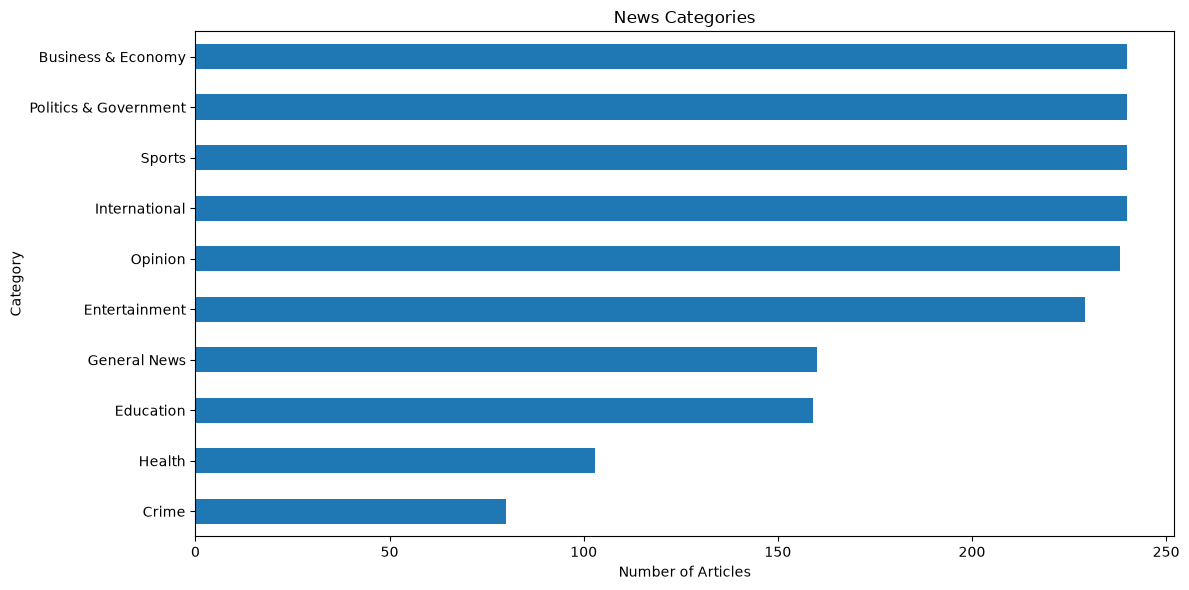

In [13]:
plt.figure(figsize=(12,6))

label_counts.sort_values().plot(kind="barh")

plt.title("News Categories")

plt.xlabel("Number of Articles")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

### Website distribution

In [14]:
website_counts = df["website"].value_counts()
website_counts

website
Ratopati    732
News24      717
Setopati    480
Name: count, dtype: int64

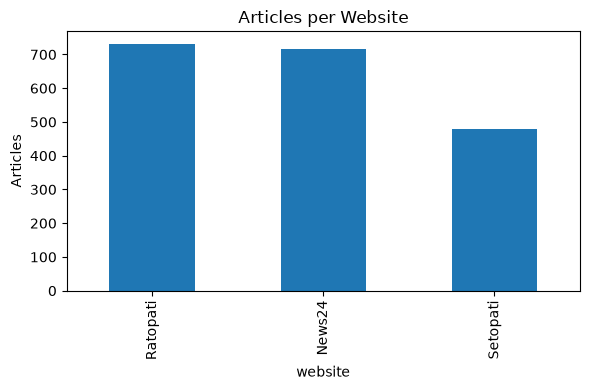

In [15]:
plt.figure(figsize=(6,4))

website_counts.plot(kind="bar")

plt.title("Articles per Website")

plt.ylabel("Articles")

plt.tight_layout()

plt.show()

In [16]:
pd.crosstab(
    df["website"],
    df["label"]
)

label,Business & Economy,Crime,Education,Entertainment,General News,Health,International,Opinion,Politics & Government,Sports
website,,,,,,,,,,
News24,80,0,79,79,80,80,80,79,80,80
Ratopati,80,80,80,70,80,23,80,79,80,80
Setopati,80,0,0,80,0,0,80,80,80,80


In [17]:
print("Number of articles:", len(df))

Number of articles: 1929


### Label Distributions

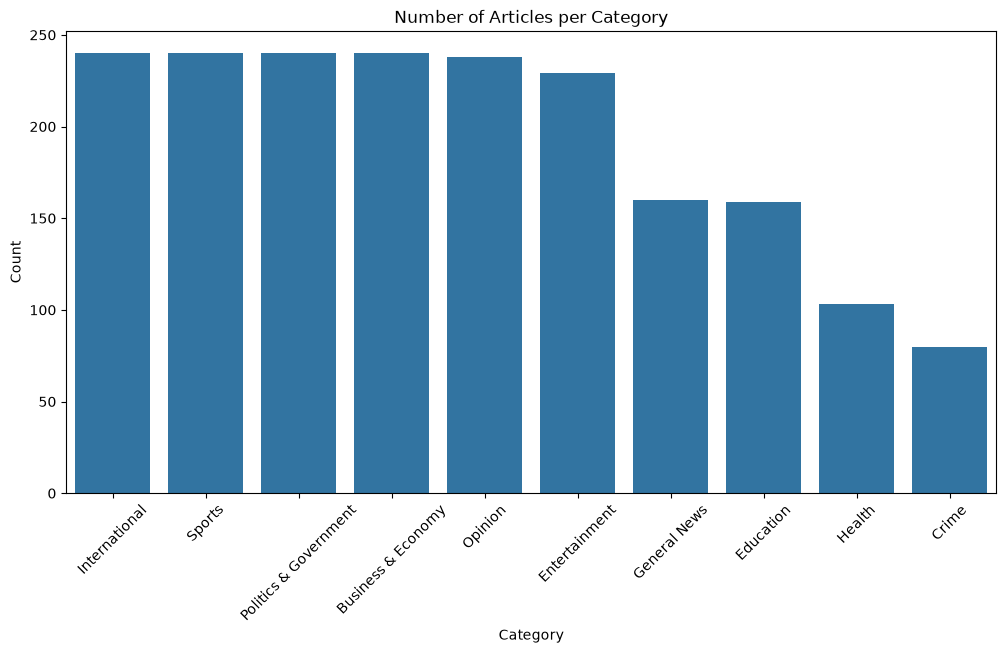

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="label",
    data=df,
    order=df["label"].value_counts().index
    
)
plt.xticks(rotation=45)
plt.title("Number of Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

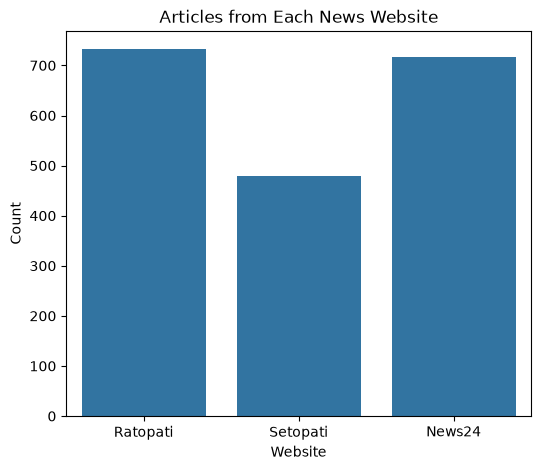

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="website"
)

plt.title("Articles from Each News Website")
plt.xlabel("Website")
plt.ylabel("Count")

plt.show()

In [20]:
pd.crosstab(
    df["website"],
    df["label"]
)

label,Business & Economy,Crime,Education,Entertainment,General News,Health,International,Opinion,Politics & Government,Sports
website,,,,,,,,,,
News24,80,0,79,79,80,80,80,79,80,80
Ratopati,80,80,80,70,80,23,80,79,80,80
Setopati,80,0,0,80,0,0,80,80,80,80


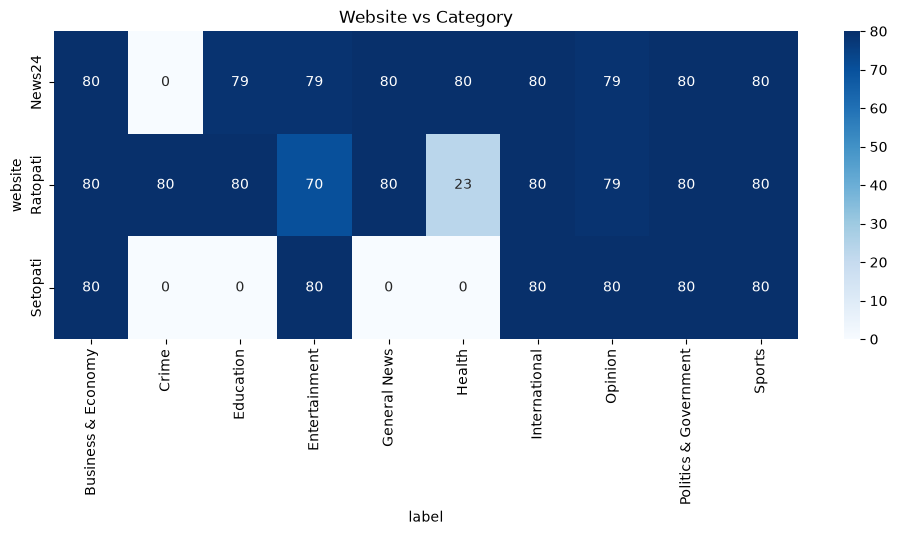

In [21]:
plt.figure(figsize=(12,4))

sns.heatmap(
    pd.crosstab(df["website"], df["label"]),
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Website vs Category")
plt.show()

In [22]:
df["title_length"] = df["title"].apply(len)

df["title_length"].describe()

count    1929.000000
mean       74.415759
std        26.296373
min        12.000000
25%        54.000000
50%        74.000000
75%        94.000000
max       191.000000
Name: title_length, dtype: float64

In [23]:
df["content_length"] = df["content"].apply(len)

df["content_length"].describe()

count     1929.000000
mean      2944.810264
std       2937.099728
min        211.000000
25%       1230.000000
50%       2055.000000
75%       3461.000000
max      25811.000000
Name: content_length, dtype: float64

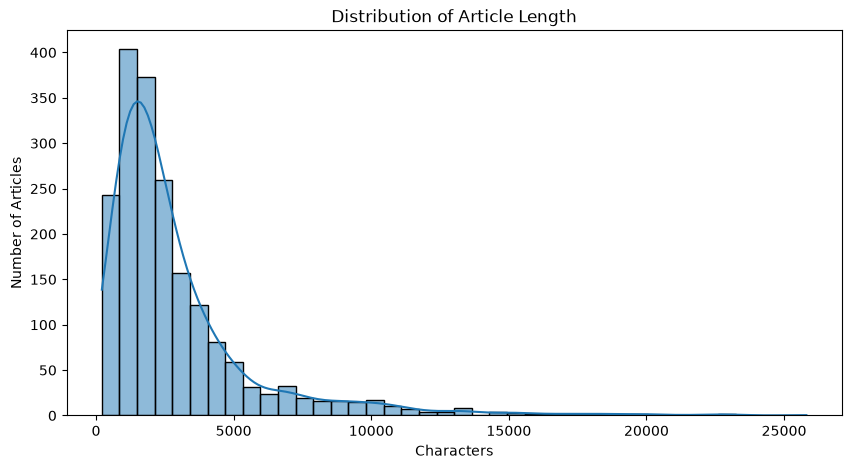

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["content_length"],
    bins=40,
    kde=True
)

plt.title("Distribution of Article Length")
plt.xlabel("Characters")
plt.ylabel("Number of Articles")

plt.show()

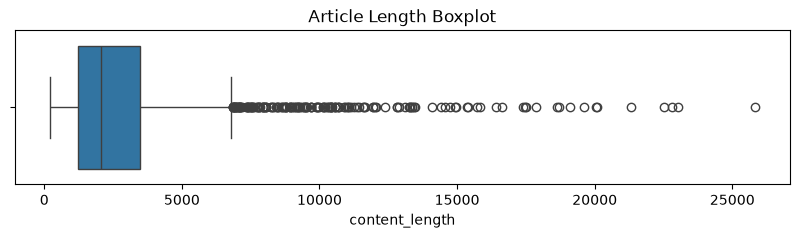

In [25]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["content_length"]
)

plt.title("Article Length Boxplot")

plt.show()

In [26]:
average_length = (
    df.groupby("label")["content_length"]
      .mean()
      .sort_values(ascending=False)
)

average_length

label
Opinion                  7133.726891
Business & Economy       2810.587500
International            2621.770833
Sports                   2588.520833
Politics & Government    2573.616667
General News             2328.568750
Education                2267.490566
Health                   2249.466019
Entertainment            1703.196507
Crime                    1065.050000
Name: content_length, dtype: float64

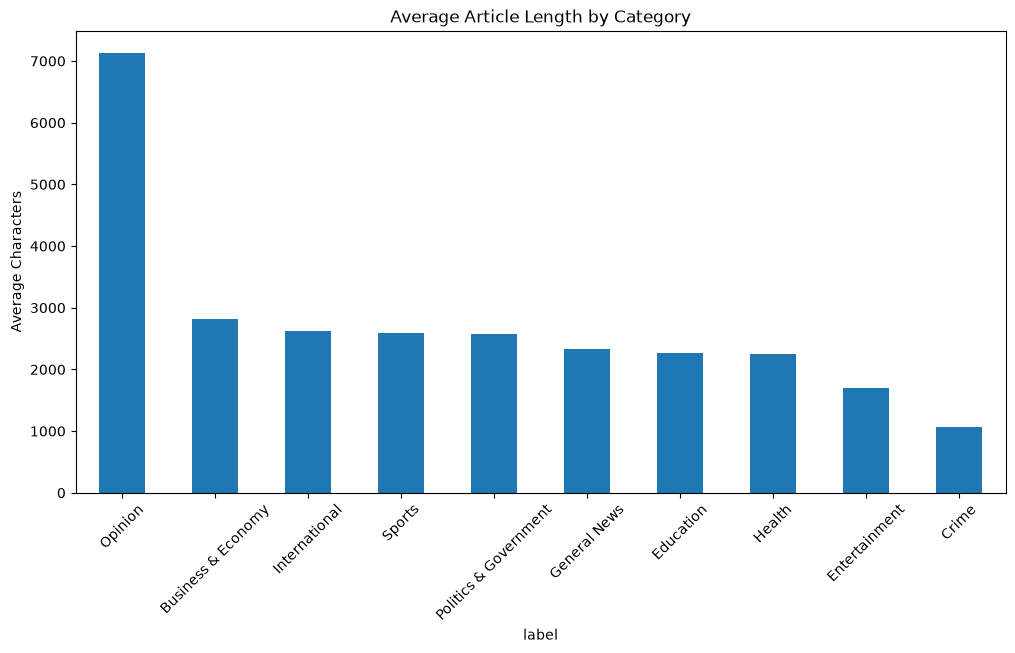

In [27]:
plt.figure(figsize=(12,6))

average_length.plot(kind="bar")

plt.ylabel("Average Characters")
plt.title("Average Article Length by Category")

plt.xticks(rotation=45)

plt.show()